In [1]:
# Another try at numerically solving the advection diffusion equation
# It seems we can just use Dirichlet boundary condition

# Test the naive explicit solution that do not take into account 
# concentration change in adjacent cells
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from tqdm import tqdm
import warnings
import xarray as xr

warnings.filterwarnings(action='error')

zsoii = np.array([0, 0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 
                1.3828, 2.2961, 3.8019])
zsoi = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607])
"""
zsoii = np.linspace(0, 1, 11)
zsoi = np.convolve(zsoii, [0.5,0.5], mode = 'valid')
"""
dz = np.diff(zsoii)

# number of soil layers
nlevsoi = 10

In [2]:
def a_step_explicit(c_prev, rain_conc, q_int, theta, watsat, sourcesink, d0, dt):
    """
    Author: Yaoping Wang, ESD, ORNL, 2025-04-15
    
    rain_conc - upper boundary condition (rain water chemistry) (mol/m3-water)
    c_prev - start concentration (mol/m3-water)
    q_int - water flux at grid boundaries (m/s)
    theta - soil moisture value (m3/m3)
    watsat - porosity
    sourcesink - source/sink strength (mol/m3-soil/s)
    d0 - diffusion coefficient in water (m2/s)
    dt - time step size (s)

    If we ignore spatial dependency, the equation becomes very simple

    Consider a generic cell C_i with adjacent cells
        C_{i-1} <--- Δ x_i ---> C_i, D_{eff,i} <--- Δ x_{i+1} ---> C_{i+1}

    Total mass change within C_i due to outflow
        Δ x  * θ * \frac{ dC_i }{ dt }

    Diffusion to the upper cell, if C_i > C_{i-1}
        dup = D_{eff,i} * I[C_i > C_{i-1}] * \frac{C_i - C_{i-1}}{Δ x_i}

    Diffusion to the lower cell, if C_i > C_{i+1}
        dlow = D_{eff,i} * I[C_i > C_{i+1}] * \frac{C_i - C_{i+1}}{Δ x_{i+1}}

    Advection to upper cell, if q_{in,i} < 0
        aup = I[q_{in,i} < 0] * abs( q_{in,i} ) * C_i

    Advection to lower cell, if q_{out,i} > 0
        alow = I[q_{out,i} > 0] * q_{out,i} * C_i

    Rain inflow
        rain = I[q_{in,i} > 0] * q_{in,0} * C_{rain}

    The relationship between self-change and the four outflow and internal source/sink, 
        after simplification, is

        Δ x * θ * \frac{ dC_i }{ dt } = 
          - ( \frac{ D_{eff,i} * I[C_i > C_{i-1}] }{Δ x_i} + 
              \frac{ D_{eff,i} * I[C_i > C_{i+1}] }{Δ x_{i+1}} + 
              I[q_{in,i} < 0] * abs( q_{in,i} ) + I[q_{out,i} > 0] * q_{out,i} ) * C_i
          + ( D_{eff,i} * I[C_i > C_{i-1}] \frac{C_{i-1}}{Δ x_i} )
          + ( D_{eff,i} * I[C_i > C_{i+1}] \frac{C_{i+1}}{Δ x_{i+1}} )
          + I[q_{in,i} > 0] * q_{in,0} * C_{rain}
          + R

        , which is of the form dC/dt = kC + r, and the analytical solution is just
             C = (C0 + r/k)e^{kt} - r/k
             on the interval [t, t + Δ t]

    The equations means when t → ∞, C → -r/k

    It is guaranteed that k < 0. Therefore, 

    if r > 0, the concentration will not be negative for large t (we can be sure )

    If r < 0, the concentration may be negative because the equilibrium value is
        negative. This can only happen when r < 0. In this case, the analytical 
        form may need to be assessed piecewise to insure non-negativity:

        Step 1. We evaluate the analytical form at (t + Δ t),
                if the resulting C_t' > C_{i-1} and C_t' > C_{i+1}, then C_t = C_t', 
                otherwise, we need to go to step 2
        Step 2. We assess piecewise: 
                first, find the dt' such that C(t + dt') = max(C_{i-1}, C_{i+1})
                then, on the interval [t+dt', t + Δ t], set the appropriate I[⋅]
                       term to 0, re-evaluate to t + Δ t
                third, if the result gives C(t + Δ t) > min(C_{i-1}, C_{i}), stop
                       otherwise, need a third piecewise, go to step 3
        Step 3. find the dt" such that C(t + dt") = min(C_{i-1}, C_{i+1}), on the
                interval [t+dt", t + Δ t], all the diffusion terms need to be 0.
                Re-integrate the pure-advection term to t + Δ t
    """
    def _analytical_c(C0, r, k, t1, t2):
        # analytical solution of dC/dt = kC + r, from t1 to t2
        c = (C0 + r/k)*np.exp(k*(t2-t1)) - r/k
        return c
    
    def _analytical_c_int(C0, r, k, t1, t2):
        # integral of the above analytical solution of C
        # over [t1, t2]
        c_int = (C0 + r/k)/k*(np.exp(k*(t2-t1))-1) - r/k*(t2-t1)
        return c_int

    def _analytical_dt(c1, c2, r, k):
        # analytical solution of the dt it takes for the above
        # analytical solution of C to evolve from c1 to c2
        dt = np.log((c2 + r/k) / (c1 + r/k)) / k
        return dt

    #zsoi = z[:nlevsoi]
    #dz   = dz[:nlevsoi]

    #
    Deff = d0 * theta**(10/3) / watsat**2
    dx = np.append(np.insert(np.diff(zsoi), 0, 100), 21) # padding; doesn't matter, so long as >0

    scale = dz * theta # \Delta x * θ on the LHS

    c_next = np.zeros(nlevsoi)
    niter = np.zeros(nlevsoi) # keep track how many piecewise integrations are done

    dc_up = np.zeros(nlevsoi) # flow upward due to diffusion and advection
    dc_down = np.zeros(nlevsoi) # flow down due to diffusion and advection

    # convert sourcesink from mol/m3-soil/s to mol/m2/s
    sourcesink = sourcesink*dz

    if q_int[0] > 0:
        sourcesink[0] = sourcesink[0] + q_int[0]*rain_conc

    for i in range(nlevsoi):

        if i == 0:
            # top layer: no diffusion to above
            i1 = 0
            i2 = int(c_prev[i] > c_prev[i+1])

        elif i < (nlevsoi-1):
            # middle layers
            i1 = int(c_prev[i] > c_prev[i-1])
            i2 = int(c_prev[i] > c_prev[i+1])

        else:
            # bottom layer: no diffusion to below
            i1 = int(c_prev[i] > c_prev[i-1])
            i2 = 0

        i3 = int(q_int[i] < 0)
        i4 = int(q_int[i+1] > 0)

        k = - (i1*Deff[i]/dx[i] + i2*Deff[i]/dx[i+1] + i3*abs(q_int[i]) + i4*q_int[i+1]) / scale[i]

        if i == 0:
            r = (Deff[i]*i2*c_prev[i+1]/dx[i+1] + sourcesink[i]) / scale[i]
        elif i < (nlevsoi-1):
            r = (Deff[i]*i1*c_prev[i-1]/dx[i] + Deff[i]*i2*c_prev[i+1]/dx[i+1] \
                 + sourcesink[i]) / scale[i]
        else:
            r = (Deff[i]*i1*c_prev[i-1]/dx[i] + sourcesink[i]) / scale[i]

        # if there is no flow out of this cell, degrades to linear source
        if k == 0:
            c_next[i] = c_prev[i] + r*dt
            dc_up[i] = 0
            dc_down[i] = 0

            continue

        # otherwise, do actual calculations

        # step 1: find end-of-step solution
        c = _analytical_c(c_prev[i], r, k, 0, dt)

        if i == 0:
            cmax = c_prev[i+1]

            # end-of-step solution works, or there is no diffusion to begin with
            if (c > cmax) | (i2 == 0):
                c_next[i] = c
                niter[i] = 1

                # integration of c over [0, dt]
                c_int = _analytical_c_int(c_prev[i], r, k, 0, dt)

                # use c_int to calculate the fluxes
                dc_up[i] = i3*abs(q_int[i])*c_int
                dc_down[i] = i2*Deff[i]/dx[i+1] * (c_int - c_prev[i+1]*dt) \
                                + i4*q_int[i+1]*c_int

            else:
                # step 2: piecewise integrate to cmax, then update k, r and continue
                dt_p = _analytical_dt(c_prev[i], cmax, r, k)

                # integration of c over [0, dt']
                c_int_p = _analytical_c_int(c_prev[i], r, k, 0, dt_p)

                # use c_int to calculate the fluxes during [0, dt']
                dc_up[i] = i3*abs(q_int[i])*c_int_p
                dc_down[i] = i2*Deff[i]/dx[i+1] * (c_int_p - c_prev[i+1]*dt_p) \
                                + i4*q_int[i+1]*c_int_p

                # update k & r (no more diffusion)
                k = - (i3*abs(q_int[i]) + i4*q_int[i+1]) / scale[i]
                r = sourcesink[i] / scale[i]

                # itegration of c over [dt', dt]
                c_int_pp = _analytical_c_int(cmax, r, k, dt_p, dt)

                # add to the fluxes
                dc_up[i] = dc_up[i] + i3*abs(q_int[i])*c_int_pp
                dc_down[i] = dc_down[i] + i4*q_int[i+1]*c_int_pp

                # find final value
                c_next[i] = _analytical_c(cmax, r, k, dt_p, dt)
                niter[i] = 2

        elif i < (nlevsoi-1):

            if (i1 == 0) & (i2 == 0):
                # if there is no diffusion to begin with, end of solution works

                # final value found
                c_next[i] = c
                niter[i] = 1

                # integration of c over [0, dt]
                c_int = _analytical_c_int(c_prev[i], r, k, 0, dt)

                # calculate the fluxes during [0, dt] (all diffusion)
                dc_up[i] = i3*abs(q_int[i])*c_int
                dc_down[i] = i4*q_int[i+1]*c_int

            else:
                # if there is only one side diffusion
                if (i1 == 0):
                    cmax = c_prev[i+1] # diffuse down
                    cmin = 0
                    i1_keep = 0
                    i2_keep = 1

                elif (i2 == 0):
                    cmax = c_prev[i-1] # diffuse up
                    cmin = 0
                    i1_keep = 1
                    i2_keep = 0

                else:
                    # both sides have diffusion, decide which side to begin with

                    if c_prev[i-1] > c_prev[i+1]:
                        cmax = c_prev[i-1]
                        cmin = c_prev[i+1]
                        i1_keep = 0
                        i2_keep = 1

                    else:
                        cmax = c_prev[i+1]
                        cmin = c_prev[i-1]
                        i1_keep = 1
                        i2_keep = 0

                # if end of solution works
                if c > cmax:

                    # final value found
                    c_next[i] = c
                    niter[i] = 1

                    # integration of c over [0, dt]
                    c_int = _analytical_c_int(c_prev[i], r, k, 0, dt)

                    # calculate the fluxes during [0, dt] (all diffusion)
                    dc_up[i] = i1*Deff[i]/dx[i] * (c_int - c_prev[i-1]*dt) \
                            + i3*abs(q_int[i])*c_int
                    dc_down[i] = i2*Deff[i]/dx[i+1] * (c_int - c_prev[i+1]*dt) \
                            + i4*q_int[i+1]*c_int

                else:
                    # step 2: piecewise integrate to cmax, then update k, r and continue
                    dt_p = _analytical_dt(c_prev[i], cmax, r, k)

                    # integration of c over [0, dt']
                    c_int_p = _analytical_c_int(c_prev[i], r, k, 0, dt_p)

                    # calculate the fluxes during [0, dt'] (all diffusion)
                    dc_up[i] = i1*Deff[i]/dx[i] * (c_int_p - c_prev[i-1]*dt_p) \
                            + i3*abs(q_int[i])*c_int_p
                    dc_down[i] = i2*Deff[i]/dx[i+1] * (c_int_p - c_prev[i+1]*dt_p) \
                            + i4*q_int[i+1]*c_int_p

                    # update k & r (drop one side of diffusion)
                    k = - (i1_keep*i1*Deff[i]/dx[i] + i2_keep*i2*Deff[i]/dx[i+1] + \
                            i3*abs(q_int[i]) + i4*q_int[i+1]) / scale[i]
                    r = (Deff[i]*i1_keep*i1*c_prev[i-1]/dx[i] + \
                         Deff[i]*i2_keep*i2*c_prev[i+1]/dx[i+1] + sourcesink[i]) / scale[i]

                    # continue to end, but we need another check
                    c_p = _analytical_c(cmax, r, k, dt_p, dt)

                    if c_p > cmin:

                        # itegration of c over [dt', dt]
                        c_int_p = _analytical_c_int(cmax, r, k, dt_p, dt)

                        # add the fluxes during [dt', dt] (drop one side of diffusion)
                        dc_up[i] = dc_up[i] \
                            + i1_keep*i1*Deff[i]/dx[i] * (c_int_p - cmax*(dt-dt_p)) \
                            + i3*abs(q_int[i])*c_int_p
                        dc_down[i] = dc_down[i] \
                            + i2_keep*i2*Deff[i]/dx[i+1] * (c_int_p - cmax*(dt-dt_p)) \
                            + i4*q_int[i+1]*c_int_p

                        # final value at dt
                        c_next[i] = _analytical_c(cmax, r, k, dt_p, dt)
                        niter[i] = 2

                    else:
                        # step 3: do another piecewise integration

                        # second stop point
                        dt_pp = _analytical_dt(cmax, cmin, r, k)

                        # itegration of c over [dt', dt"]
                        c_int_pp = _analytical_c_int(c_p, r, k, dt_p, dt_pp)

                        # add the fluxes during [dt', dt"] (drop one side of diffusion)
                        dc_up[i] = dc_up[i] \
                            + i1_keep*i1*Deff[i]/dx[i] * (c_int_pp - cmin*(dt_pp-dt_p)) \
                            + i3*abs(q_int[i])*c_int_pp
                        dc_down[i] = dc_down[i] \
                            + i2_keep*i2*Deff[i]/dx[i+1] * (c_int_pp - cmin*(dt_pp-dt_p)) \
                            + i4*q_int[i+1]*c_int_pp

                        # update the k & r (drop all diffusion)
                        k = - (i3*abs(q_int[i]) + i4*q_int[i+1]) / scale[i]
                        r = sourcesink[i] / scale[i]

                        # itegration of c over [dt", dt]
                        c_int_pp = _analytical_c_int(cmin, r, k, dt_pp, dt)

                        # add the fluxes during [dt", dt]
                        dc_up[i] = dc_up[i] + i3*abs(q_int[i])*c_int_pp
                        dc_down[i] = dc_down[i] + i4*q_int[i+1]*c_int_pp

                        # final value
                        c_next[i] = _analytical_c(cmin, r, k, dt_pp, dt)
                        niter[i] = 3

        # last soil layer
        else:
            cmax = c_prev[i-1]

            # end-of-step solution works, or there is no diffusion to begin with 
            if (c > cmax) | (i1 == 0):
                c_next[i] = c
                niter[i] = 1

                # integration of c over [0, dt]
                c_int = _analytical_c_int(c_prev[i], r, k, 0, dt)

                # use c_int to calculate the fluxes
                dc_up[i] = i1*Deff[i]/dx[i] * (c_int - c_prev[i-1]*dt) \
                           + i3*abs(q_int[i])*c_int
                dc_down[i] = i4*q_int[i+1]*c_int

            else:
                # step 2: piecewise integrate to cmax, then update k, r and continue
                dt_p = _analytical_dt(c_prev[i-1], cmax, r, k)

                # integration of c over [0, dt']
                c_int_p = _analytical_c_int(c_prev[i], r, k, 0, dt_p)

                # calculate the fluxes during [0, dt'] (all diffusion)
                dc_up[i] = i1*Deff[i]/dx[i] * (c_int_p - c_prev[i-1]*dt_p) \
                           + i3*abs(q_int[i])*c_int_p
                dc_down[i] = i4*q_int[i+1]*c_int_p

                # update k & r (no more diffusion)
                k = - (i3*abs(q_int[i]) + i4*q_int[i+1]) / scale[i]
                r = sourcesink[i] / scale[i]

                # itegration of c over [dt', dt]
                c_int_pp = _analytical_c_int(cmax, r, k, dt_p, dt)

                # add to the fluxes
                dc_up[i] = dc_up[i] + i3*abs(q_int[i])*c_int_pp
                dc_down[i] = dc_down[i] + i4*q_int[i+1]*c_int_pp

                # find final value
                c_next[i] = _analytical_c(cmax, r, k, dt_p, dt)
                niter[i] = 2

    # we still need to catch the case when r is simply too negative
    # in that case, we really need to reduce r (secondary mineral
    # precipitation, etc.)
    # (TBD)

    #print( 'dc', (c_next - c_prev)*dz*theta )
    #print( 'q_int', q_int)
    #print( 'dc_up', dc_up )
    #print( 'dc_down', dc_down )
    #print( 'dc - outflux', (c_next - c_prev)*dz*theta + (dc_up + dc_down))
    #print(sum(dc_up + dc_down))
    #print(sum((c_next - c_prev)*dz*theta))
    #print(sum((c_next - c_prev)*dz*theta + (dc_up + dc_down)))

    # calculate the net between self-outflow and inflow fluxes
    # note the inflow fluxes need to be scaled by soil moisture
    # to get the correct concentration implications
    c_next[:-1] = c_next[:-1] + dc_up[1:]/theta[:-1]/dz[:-1]
    c_next[1:] = c_next[1:] + dc_down[:-1]/theta[1:]/dz[1:]

    for i in range(nlevsoi):
        if (c_next[i] < 0):
            print(i, c_next[i], dc_up[i+1]/theta[i]/dz[i], dc_down[i-1]/theta[i]/dz[i])
            dummy()

    return c_next, niter


In [3]:
# initial concentration (mol kg-1 water)
c0 = np.zeros(nlevsoi)

# porosity
watsat = np.ones(nlevsoi)*0.6 # hr['watsat'][:, :nlevsoi, 0].values 

# water diffusion coefficient: m2/s
d0 = 7.93e-10 # Ca2+

# constant source strength: mol L-1 (soil volume) s-1
sourcesink = np.zeros(nlevsoi)
sourcesink[0] = 1e-5

100%|██████████| 30/30 [00:00<00:00, 7639.43it/s]


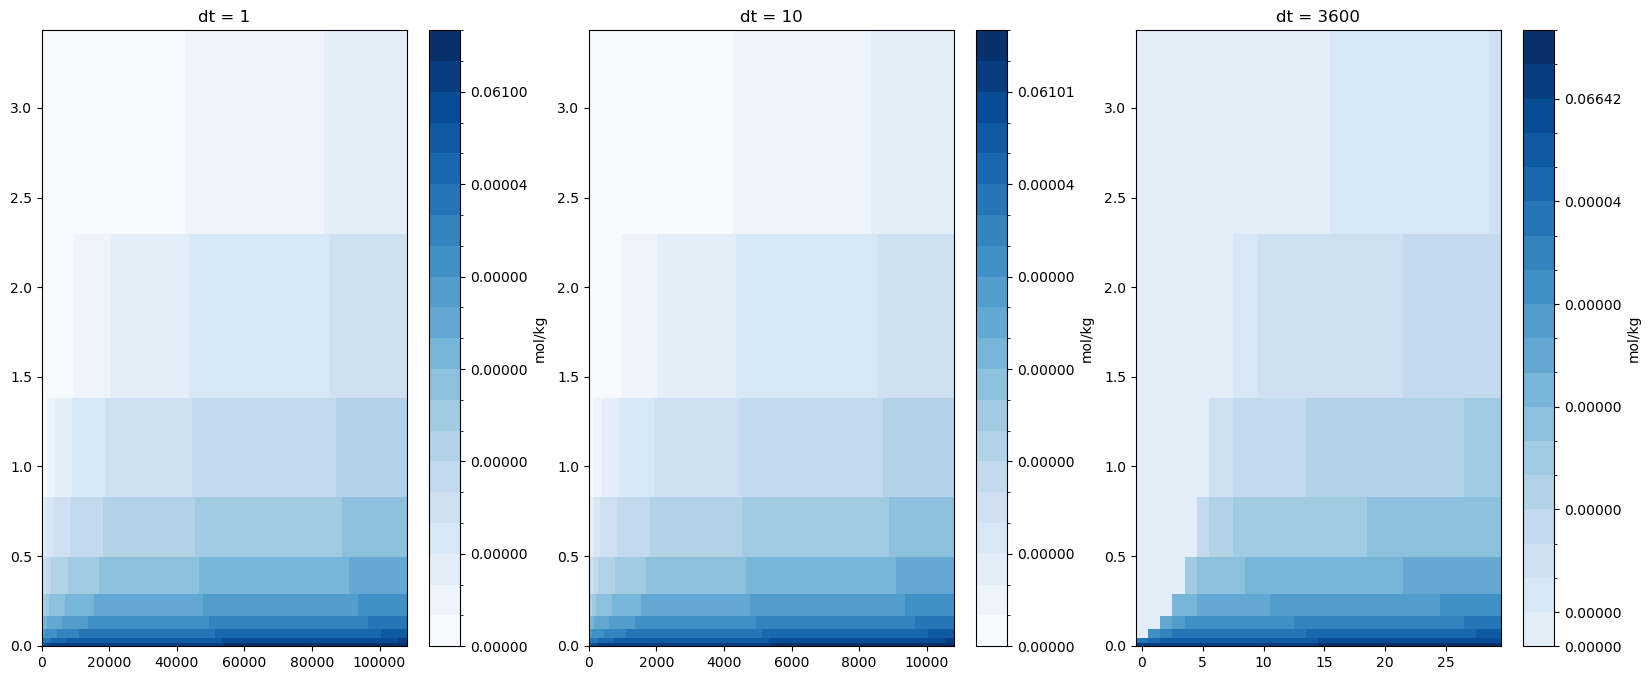

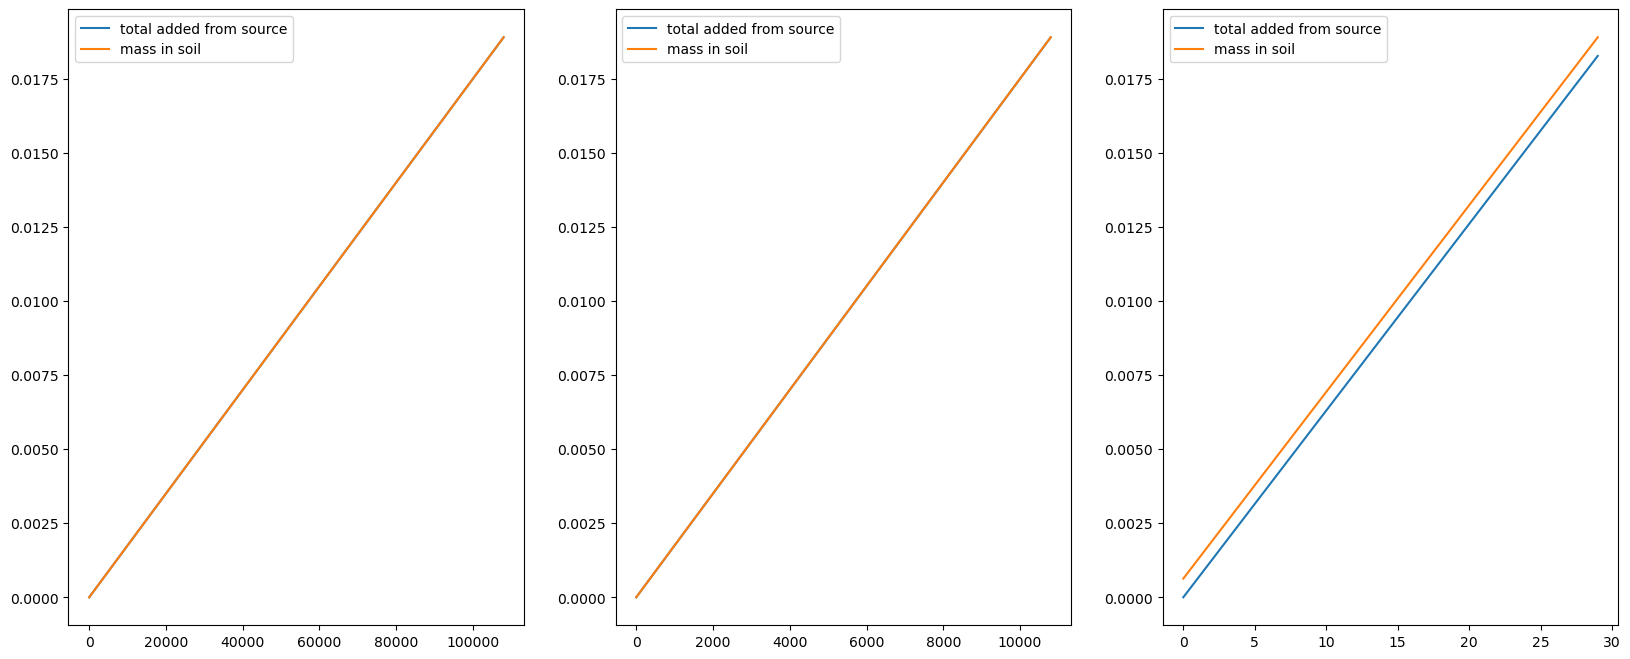

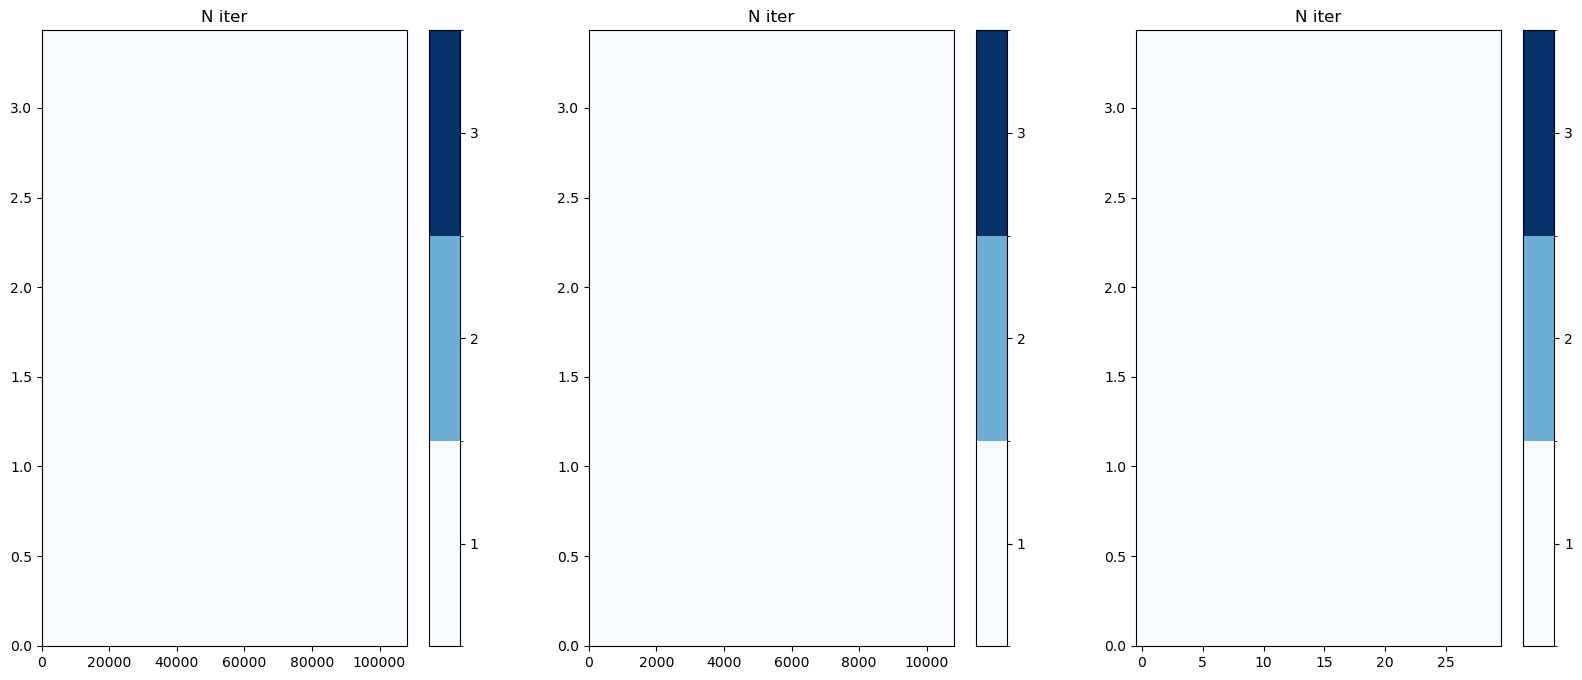

In [4]:
# constant flow rate (m/s)
# at 1e-10 the algorithm works well, at 1e-4 it is terrible
q_int = np.ones(nlevsoi+1) * 1e-10

# constant soil moisture
h2osoi = np.ones(nlevsoi) * 0.4

# size of time step
length = 3600*30
result_all = {}
niter_all = {}
for i, dt in enumerate([1,10,3600]):
    c_prev = c0
    result = np.full([length//dt, nlevsoi], np.nan)
    niter = np.full([length//dt, nlevsoi], np.nan)
    for t in tqdm(range(length//dt)):
        result[t, :], niter[t, :] = a_step_explicit(c_prev, 0, q_int, h2osoi, watsat, 
                                                    sourcesink, d0, dt)
        c_prev = result[t, :]
    result_all[dt] = result
    niter_all[dt] = niter

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    result = result_all[dt]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'dt = {dt}')
plt.savefig('test_main2.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]

    result = result_all[dt]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, length//dt) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, niter_all[dt].T, 
                        norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, ticks = [1,2,3])
    ax.set_title('N iter')

100%|██████████| 10/10 [00:00<00:00, 3796.78it/s]


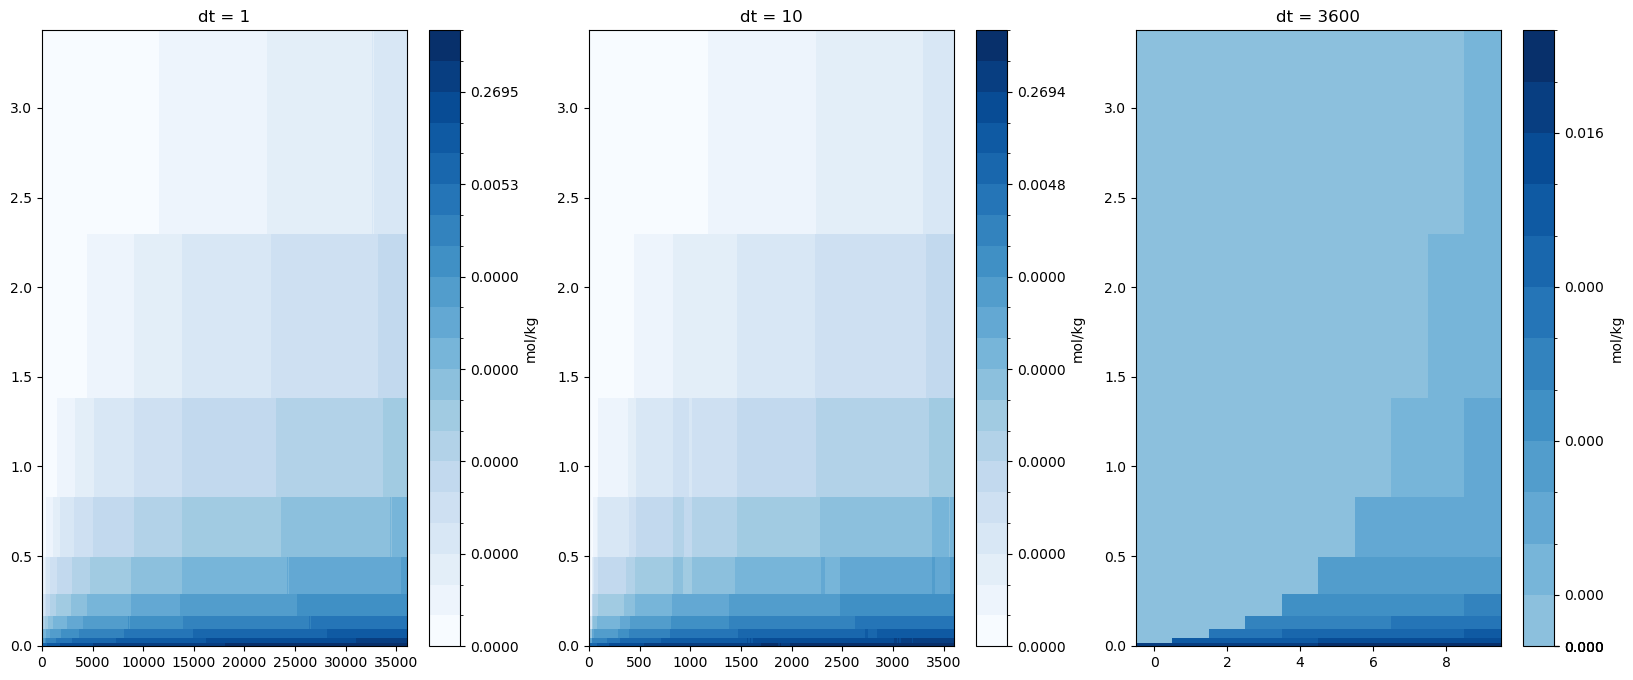

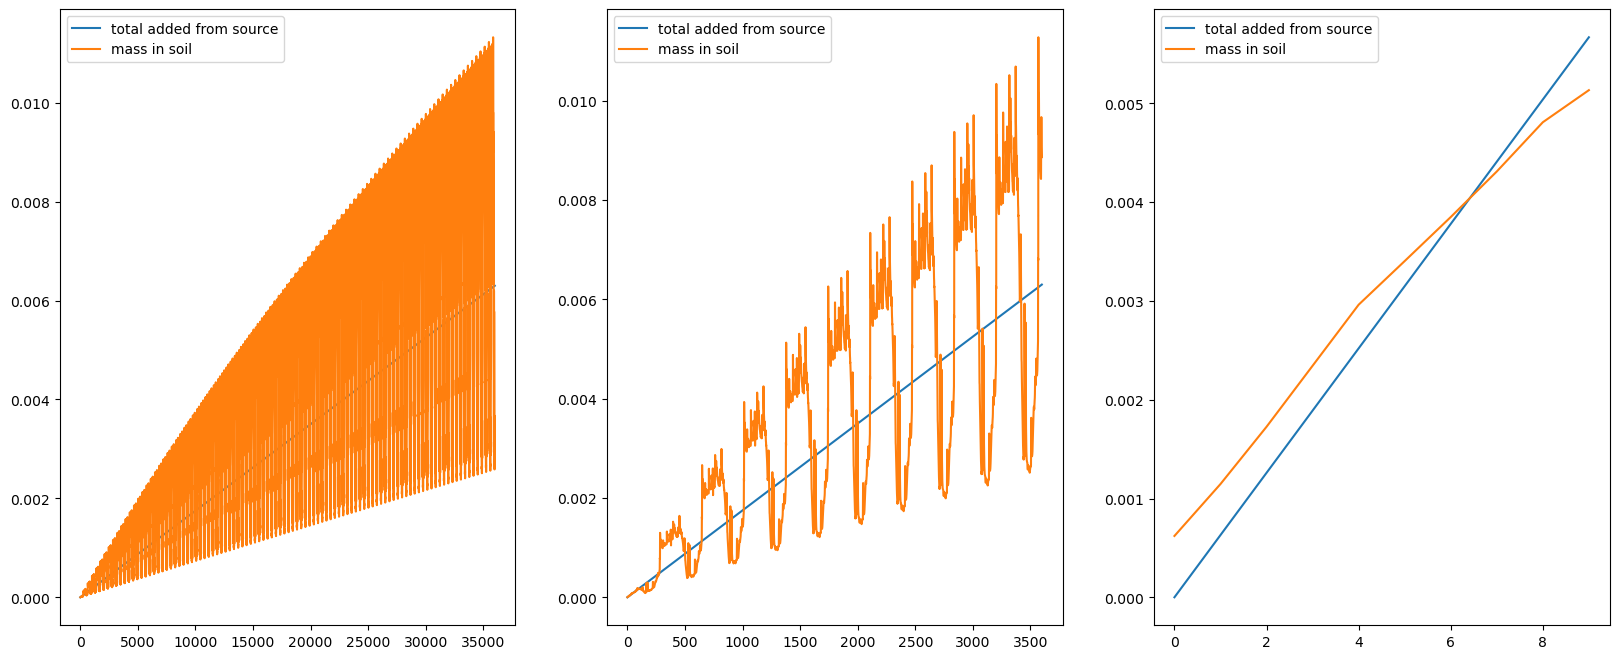

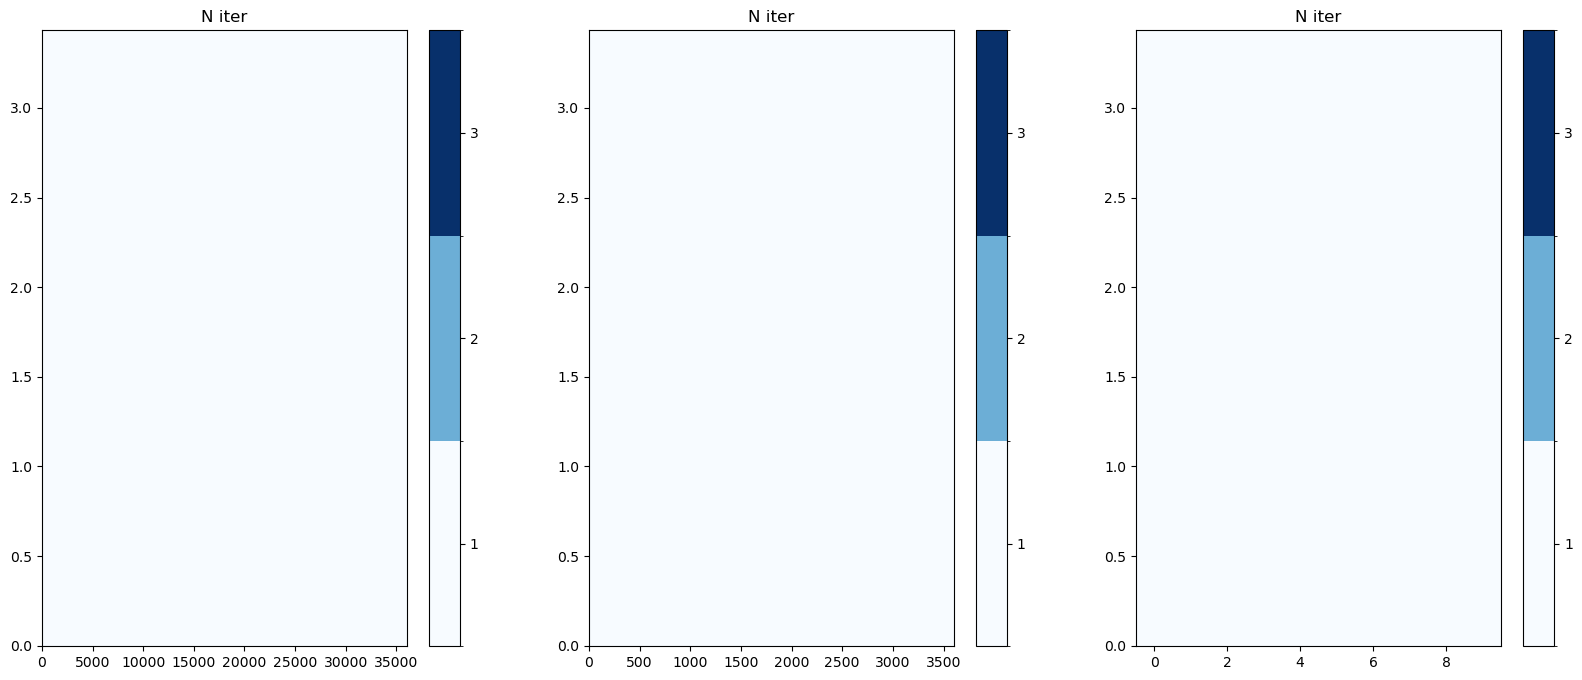

In [5]:
# realistic flow rate and soil moisture
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()

# size of time step
length = 3600*10
result_all = {}
h2o_all = {}
niter_all = {}
for i, dt in enumerate([1,10,3600]):
    c_prev = c0
    result = np.full([length//dt, nlevsoi], np.nan)
    h2osoi_record = np.full([length//dt, nlevsoi], np.nan)
    niter = np.full([length//dt, nlevsoi], np.nan)

    for t in tqdm(range(length//dt)):
        result[t, :], niter[t, :] = a_step_explicit(c_prev, 0,
            q_int[np.mod(t, len(q_int)),:], # repeat the same cycle
            h2osoi[np.mod(t, len(q_int)),:], # repeat the same cycle
            watsat, sourcesink, d0, dt)
        c_prev = result[t, :]

        h2osoi_record[t, :] = h2osoi[np.mod(t, len(q_int)),:]

    result_all[dt] = result
    h2o_all[dt] = h2osoi_record
    niter_all[dt] = niter

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    result = result_all[dt]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'dt = {dt}')
plt.savefig('test_main2_2.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]

    result = result_all[dt]
    tot_in = np.sum(result * h2o_all[dt] * dz.reshape(1,-1), axis = 1)
    total_added = np.arange(0, len(tot_in)) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, niter_all[dt].T, 
                        norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, ticks = [1,2,3])
    ax.set_title('N iter')

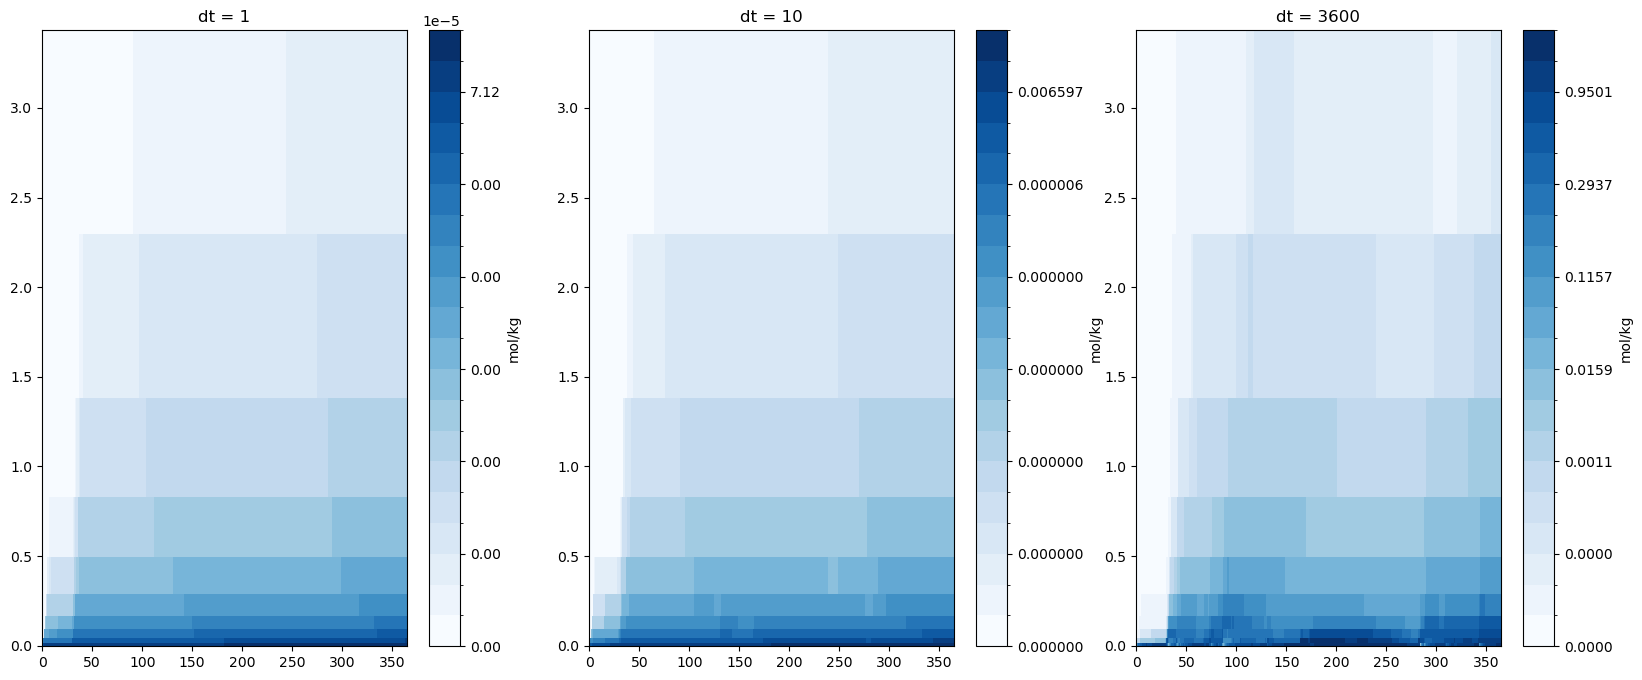

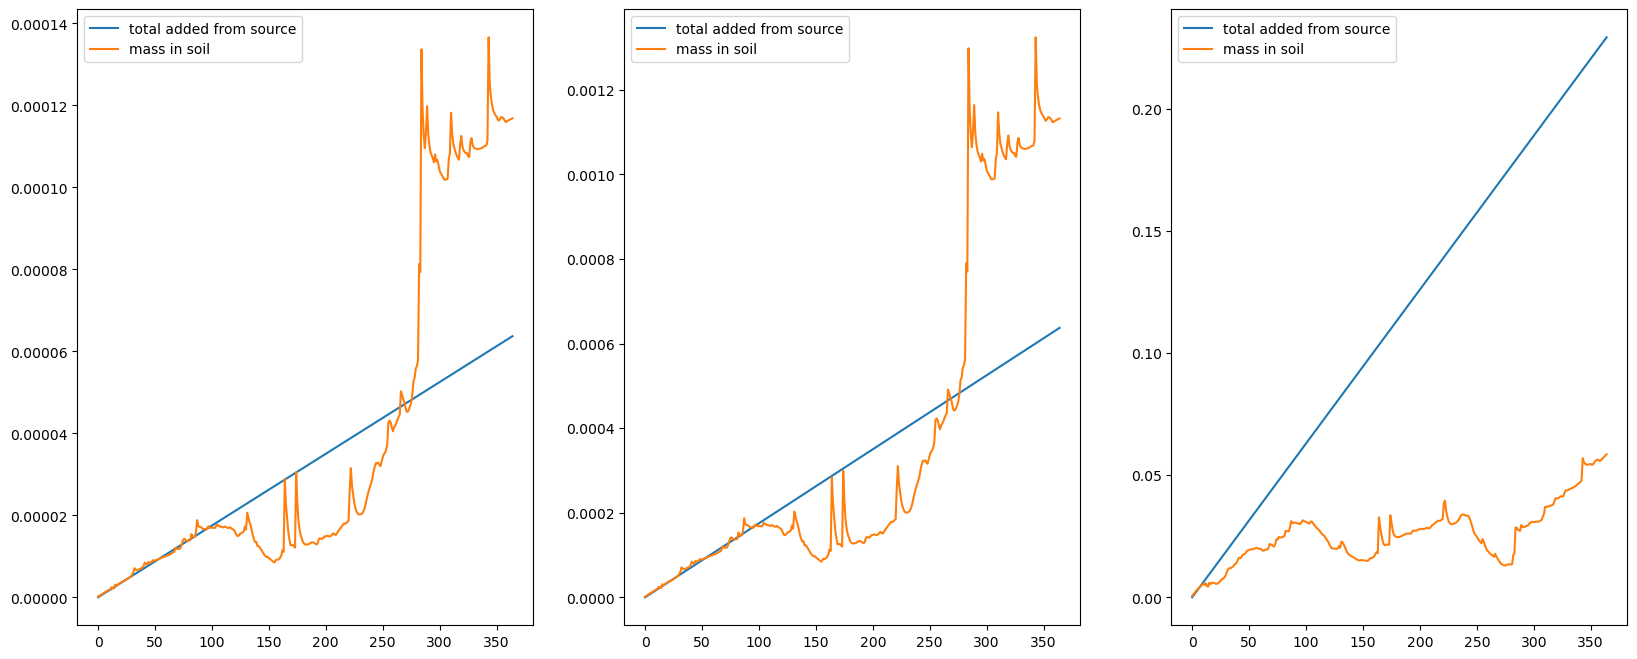

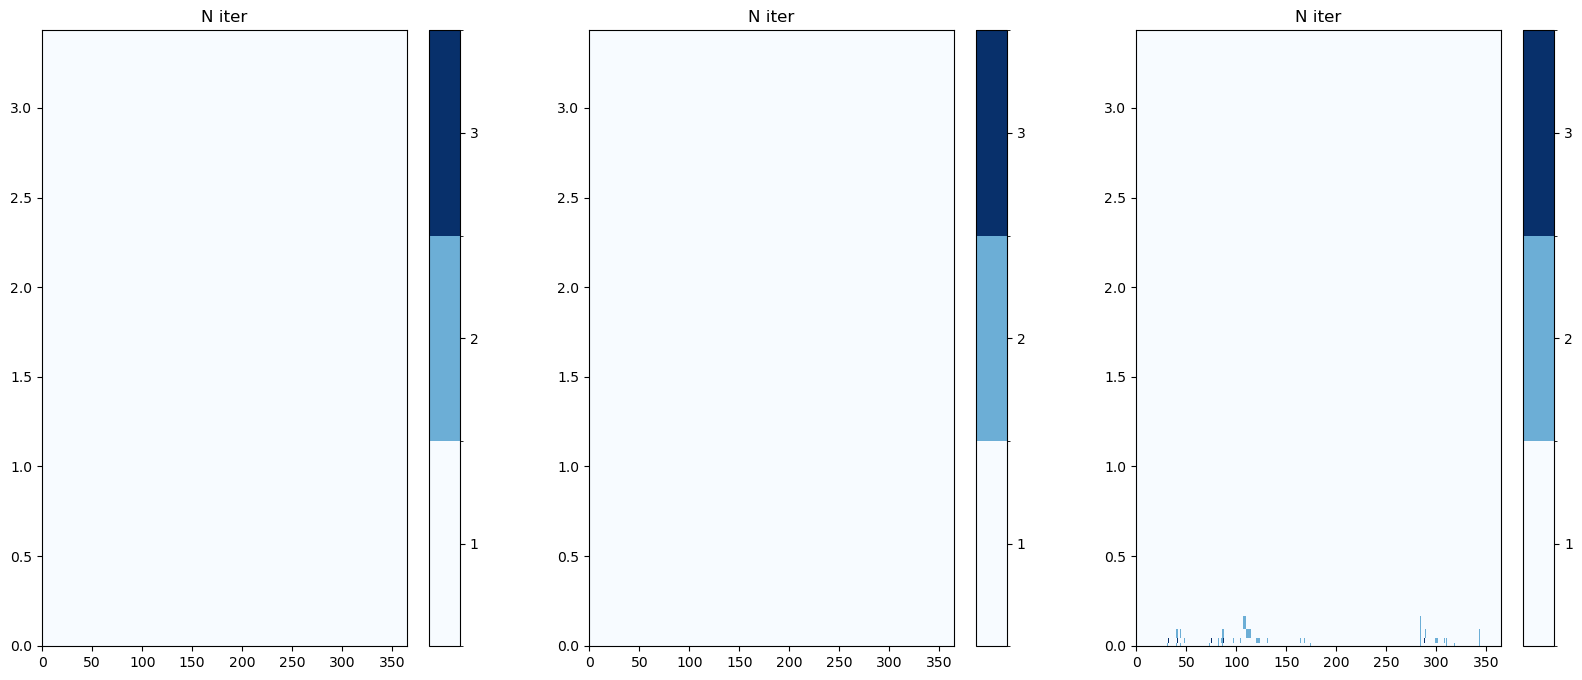

In [6]:
# non-cyclic, same forcing
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()


result_all = {}
niter_all = {}
for i, dt in enumerate([1,10,3600]):
    c_prev = c0
    result = np.full([365, nlevsoi], np.nan)
    niter = np.full([365, nlevsoi], np.nan)
    for t in range(365):
        result[t, :], niter[t, :] = a_step_explicit(c_prev, 0, q_int[t,:], h2osoi[t,:], watsat,
                                                    sourcesink, d0, dt)
        c_prev = result[t, :]

    result_all[dt] = result
    niter_all[dt] = niter

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    result = result_all[dt]
    cf = ax.pcolormesh(np.arange(365), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'dt = {dt}')
plt.savefig('test_main3.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]

    result = result_all[dt]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, 365) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

fig, axes = plt.subplots(1, 3, figsize = (20, 8))
for i, dt in enumerate([1,10,3600]):
    ax = axes.flat[i]
    cf = ax.pcolormesh(np.arange(0, 365), zsoi, niter_all[dt].T, 
                        norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, ticks = [1,2,3])
    ax.set_title('N iter')